In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [2]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = './processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

BATCH_SIZE = 128
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


In [3]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [4]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from ./processed_data/quickdraw_train.npz...


Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000



  Pancake  |  params: 1,872,911
  Ep   1/40 | tr 0.614 | val 0.696
  Ep   2/40 | tr 0.714 | val 0.728
  Ep   3/40 | tr 0.740 | val 0.734
  Ep   4/40 | tr 0.757 | val 0.746
  Ep   5/40 | tr 0.773 | val 0.759
  Ep   6/40 | tr 0.797 | val 0.760
  Ep   7/40 | tr 0.822 | val 0.775
  Ep   8/40 | tr 0.840 | val 0.775
  Ep   9/40 | tr 0.867 | val 0.785
  Ep  10/40 | tr 0.885 | val 0.779
  Ep  11/40 | tr 0.903 | val 0.783
  Ep  12/40 | tr 0.921 | val 0.785
  Ep  13/40 | tr 0.934 | val 0.787
  Ep  14/40 | tr 0.946 | val 0.789
  Ep  15/40 | tr 0.954 | val 0.789
  Ep  16/40 | tr 0.962 | val 0.788
  Ep  17/40 | tr 0.969 | val 0.788
  Ep  18/40 | tr 0.974 | val 0.791
  Ep  19/40 | tr 0.979 | val 0.793
  Ep  20/40 | tr 0.982 | val 0.791
  Ep  21/40 | tr 0.984 | val 0.793
  Ep  22/40 | tr 0.987 | val 0.792
  Ep  23/40 | tr 0.989 | val 0.792
  Ep  24/40 | tr 0.991 | val 0.795
  Ep  25/40 | tr 0.993 | val 0.793
  Ep  26/40 | tr 0.994 | val 0.795
  Ep  27/40 | tr 0.995 | val 0.795
  Ep  28/40 | tr 0.996

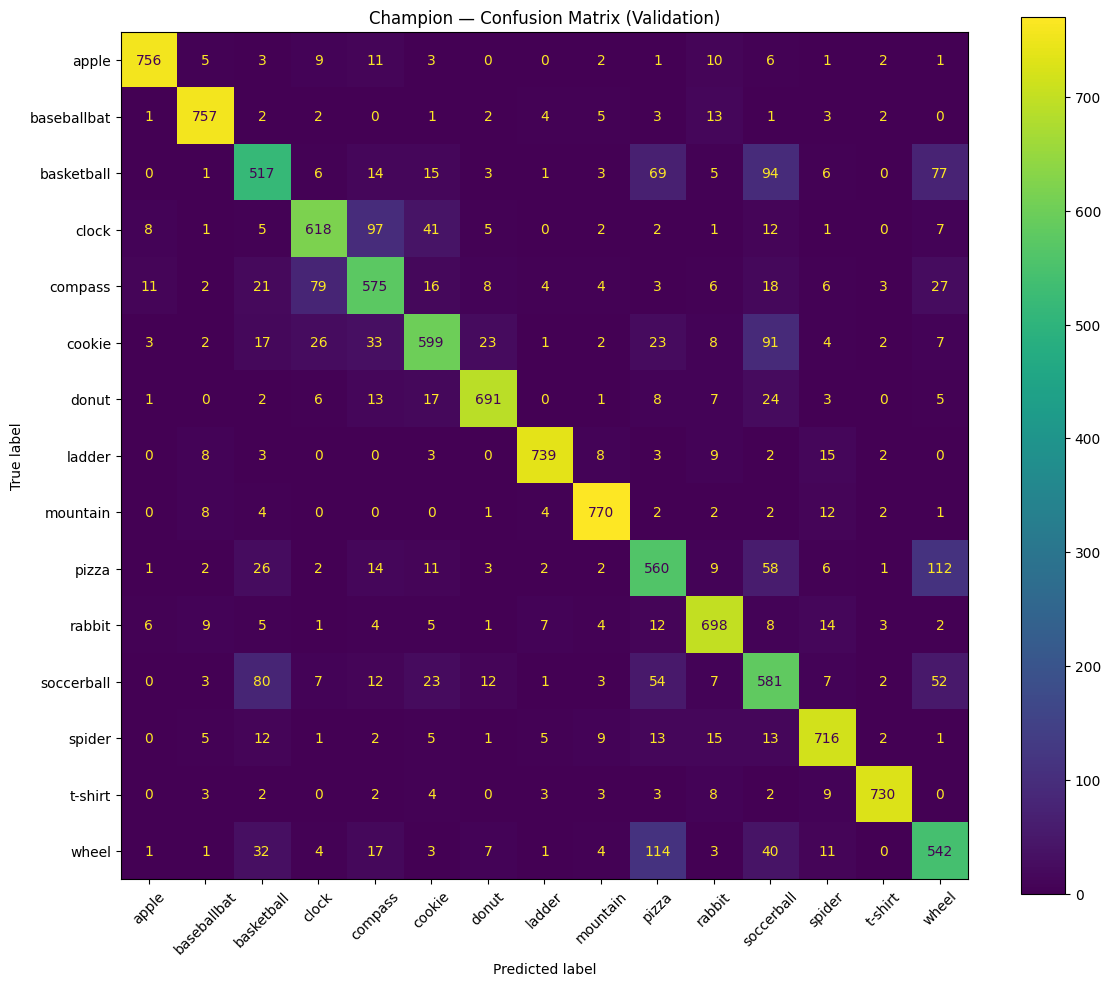

Saved confusion.png

Top 5 confused pairs:
  wheel           → pizza          : 114 errors
  pizza           → wheel          : 112 errors
  clock           → compass        : 97 errors
  basketball      → soccerball     : 94 errors
  cookie          → soccerball     : 91 errors

Model            Params  Epochs  Note
-------------------------------------------------------
Pancake       1,872,911      40
Tower           715,599      40
Champion        833,551      40


In [63]:
# ==========================================
# 4. YOUR IMPLEMENTATION HERE
# ==========================================
INPUT_SIZE  = 784   
# NUM_CLASSES is already set above from the dataset

class PancakeMLP(nn.Module):
    def __init__(self):
        super().__init__()
        W = 1350
        self.net = nn.Sequential(
            nn.Linear(INPUT_SIZE, 1024), nn.BatchNorm1d(1024), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(1024, 1024),          nn.BatchNorm1d(1024), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(1024, NUM_CLASSES)
        )
    def forward(self, x):
        return self.net(x.view(-1, INPUT_SIZE))

class TowerMLP(nn.Module):
    def __init__(self):
        super().__init__()
        W, D = 192, 16
        layers = [nn.Linear(INPUT_SIZE, W), nn.BatchNorm1d(W), nn.GELU(), nn.Dropout(0.2)]
        for _ in range(D - 1):
            layers += [nn.Linear(W, W), nn.BatchNorm1d(W), nn.GELU(), nn.Dropout(0.2)]
        layers += [nn.Linear(W, NUM_CLASSES)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x.view(-1, INPUT_SIZE))

class ChampionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # nn.Linear(INPUT_SIZE, 1024),        nn.BatchNorm1d(1024),  nn.LeakyReLU(), nn.Dropout(0.50),
           nn.Linear(INPUT_SIZE, 512),        nn.BatchNorm1d(512),  nn.GELU(), nn.Dropout(0.50),
            nn.Linear(512,  512),        nn.BatchNorm1d(512),  nn.GELU(), nn.Dropout(0.10),
            nn.Linear(512,  256),        nn.BatchNorm1d(256),  nn.GELU(), nn.Dropout(0.05),
            nn.Linear(256,128),        nn.BatchNorm1d(128),  nn.GELU(),
            nn.Linear(128,  NUM_CLASSES)
        )
    def forward(self, x):
        return self.net(x.view(-1, INPUT_SIZE))



def train_model(model, train_loader, val_loader, epochs, lr, name,weight_decay=1e-4):
    model = model.to(DEVICE)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{'='*50}")
    print(f"  {name}  |  params: {total_params:,}")
    print(f"{'='*50}")

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr,
        steps_per_epoch=len(train_loader), epochs=epochs,
        final_div_factor=1000, pct_start=0.2,div_factor=25
    )

    history = {"tr_acc": [], "val_acc": [], "tr_loss": [], "val_loss": []}
    best_val_acc, best_state = 0.0, None

    for ep in range(1, epochs + 1):
        # ── Train ──
        model.train()
        tr_loss, tr_correct, tr_total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            if name == "Champion":
                xb = xb + 0.0001 * torch.randn_like(xb)
                if torch.rand(1) > 0.5:
                    xb = xb.view(-1, 28, 28).flip(2).view(-1, 784)
                    # xb = xb.view(-1, 28, 28).flip(1).view(-1, 784)
                mask = torch.rand_like(xb) > 0.99
                xb[mask] = 0
                xb = xb.clamp(0, 1)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            tr_loss    += loss.item() * len(yb)
            tr_correct += (logits.argmax(1) == yb).sum().item() 
            # loss = criterion(model(xb), yb)
            # loss.backward()
            # nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            # optimizer.step()
            # scheduler.step()
            # tr_loss    += loss.item() * len(yb)
            # tr_correct += (model(xb).argmax(1) == yb).sum().item()
            tr_total   += len(yb)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                val_loss    += criterion(logits, yb).item() * len(yb)
                val_correct += (logits.argmax(1) == yb).sum().item()
                val_total   += len(yb)

        tr_a  = tr_correct  / tr_total
        val_a = val_correct / val_total
        history["tr_acc"].append(tr_a);    history["val_acc"].append(val_a)
        history["tr_loss"].append(tr_loss/tr_total); history["val_loss"].append(val_loss/val_total)

        if val_a > best_val_acc:
            best_val_acc = val_a
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # if ep % 5 == 0 or ep == 1:
        print(f"  Ep {ep:3d}/{epochs} | tr {tr_a:.3f} | val {val_a:.3f}")

    model.load_state_dict(best_state)
    torch.save(best_state, f"{name}_best.pth")
    print(f"  Best val acc: {best_val_acc:.4f} → saved {name}_best.pth")
    return model, history




def plot_confusion(model, val_loader, class_names):
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            all_preds.extend(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
            all_labels.extend(yb.numpy())
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(12, 10))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, xticks_rotation=45, colorbar=True)
    plt.title("Champion — Confusion Matrix (Validation)")
    plt.tight_layout()
    plt.savefig("confusion.png", dpi=150)
    plt.show()
    print("Saved confusion.png")
    np.fill_diagonal(cm, 0)
    pairs = [(cm[i,j], class_names[i], class_names[j])
             for i in range(len(class_names)) for j in range(len(class_names)) if i!=j]
    print("\nTop 5 confused pairs:")
    for cnt, a, b in sorted(pairs, reverse=True)[:5]:
        print(f"  {a:15s} → {b:15s}: {cnt} errors")



histories_pac =  []
histories_tow = []
histories = []
# pancake, tower = None, None

pancake = PancakeMLP()
pancake, h_1 = train_model(pancake, train_loader, val_loader, epochs=40, lr=3e-3, name="Pancake",weight_decay=2e-4)
histories_pac.append(h_1)

tower = TowerMLP()
tower, h_t = train_model(tower, train_loader, val_loader, epochs=40, lr=1e-3, name="Tower")
histories_tow.append(h_t)

model = ChampionMLP()   
model, h_c = train_model(model, train_loader, val_loader, epochs=40, lr=1e-2, name="Champion",weight_decay=9e-4)
histories.append(h_c)


# plot_history(histories, "Champion")

plot_confusion(model, val_loader, list(full_train_dataset.classes))


print("\n" + "="*55)
print(f"{'Model':<12} {'Params':>10}  {'Epochs':>6}  Note")
print("-"*55)
for m, ep, nm in [(pancake,40,"Pancake"), (tower,40,"Tower"), (model,40,"Champion")]:
    p = sum(x.numel() for x in m.parameters() if x.requires_grad)
    print(f"{nm:<12} {p:>10,}  {ep:>6}")
print("="*55)

In [67]:
def plot_history(all_histories, names,out_img="curves.png"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = "#2a9d8f"
    for h in all_histories:
        eps = range(1, len(h["tr_acc"]) + 1)
        axes[0].plot(eps, h["tr_acc"],  "--", color=colors, label=f"{names} train")
        axes[0].plot(eps, h["val_acc"], "-",  color=colors, label=f"{names} val")
        axes[1].plot(eps, h["tr_loss"], "--", color=colors, label=f"{names} train")
        axes[1].plot(eps, h["val_loss"],"-",  color=colors, label=f"{names} val")
    for ax, title in zip(axes, ["Accuracy", "Loss"]):
        ax.set_xlabel("Epoch"); ax.set_ylabel(title)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.suptitle(f"Training vs Validation — {names} ")
    plt.tight_layout()
    plt.savefig(out_img, dpi=150)
    plt.show()
    print("Saved curves.png")

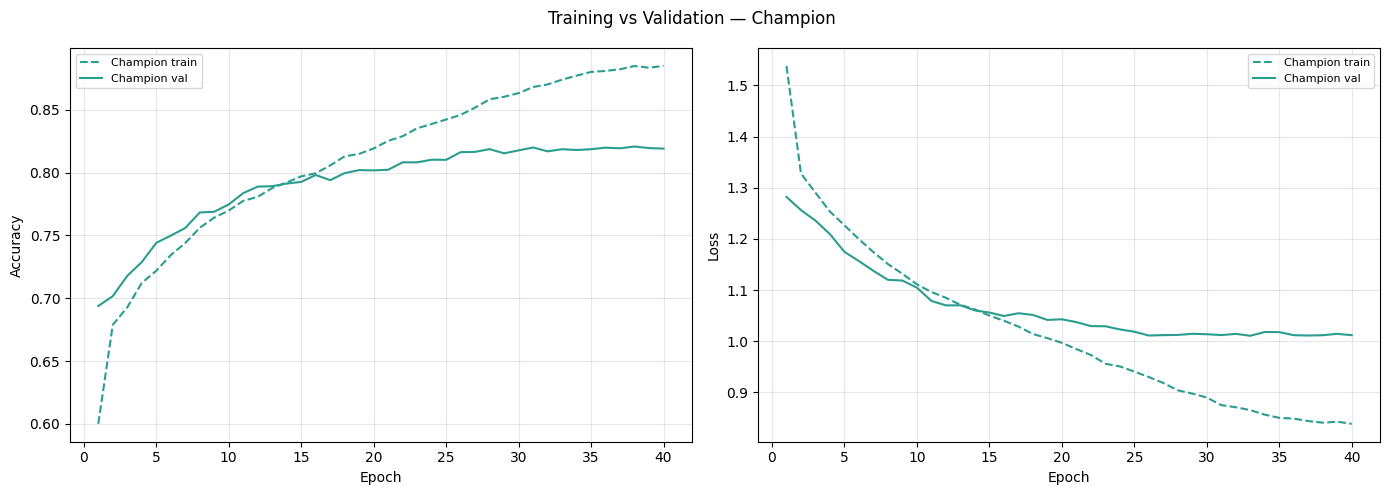

Saved curves.png


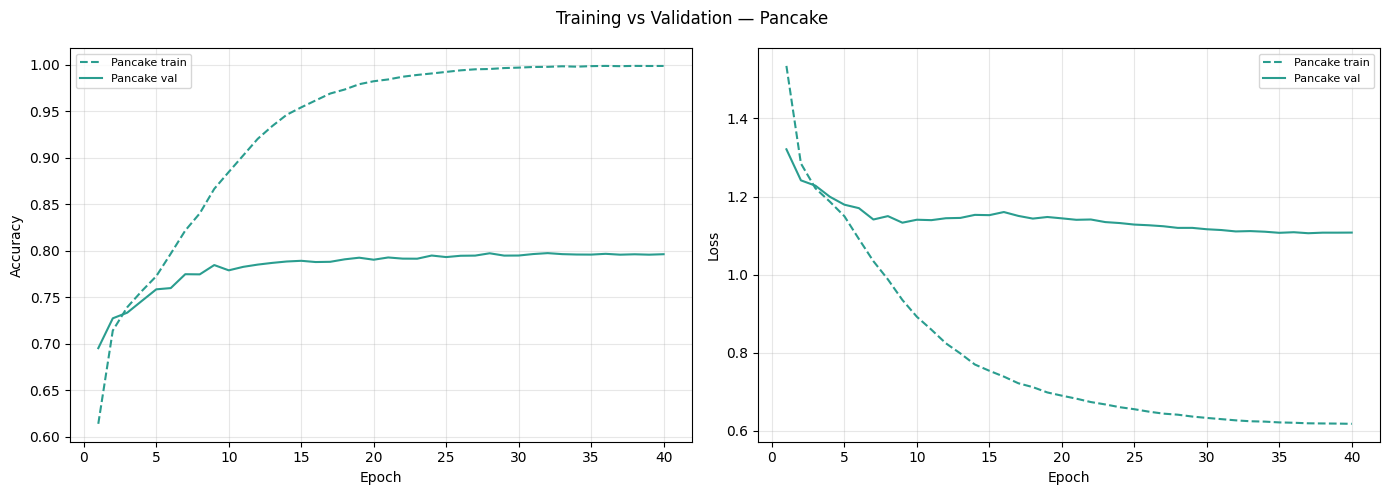

Saved curves.png


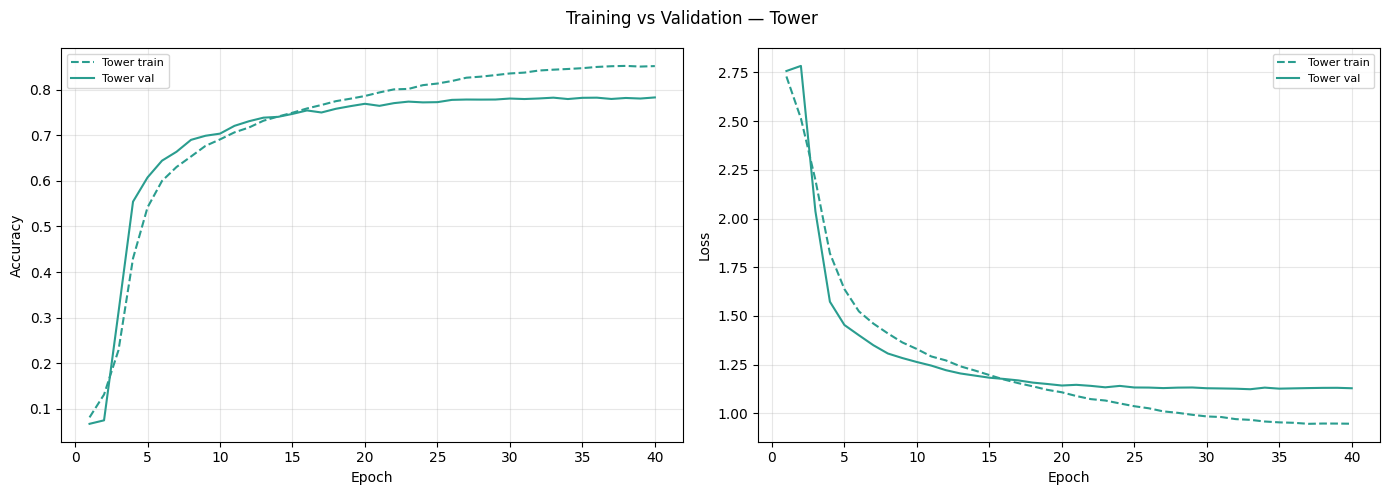

Saved curves.png


In [69]:
plot_history(histories, "Champion",out_img="champion_curves.png")
plot_history(histories_pac, "Pancake",out_img="pancake_curves.png")
plot_history(histories_tow, "Tower",out_img="tower_curves.png")

In [70]:
import pandas as pd
from sklearn.metrics import accuracy_score

# ==========================================
# 5. INFERENCE & LEADERBOARD VERIFICATION
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)
# 1. Load Test Images
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

# 2. Run Inference
print("Running inference on test set...")
predictions = get_predictions(model, test_loader)

# 3. Save as Comma-Separated Text File
submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")

# Convert list of ints to comma-separated string (e.g., "0,4,9,2...")
submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")


   GENERATING SUBMISSION FILE
Loading test data from ./processed_data/quickdraw_test.npz...
Loaded 15000 test images.
Running inference on test set...
Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.


In [71]:
def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3000000:
        print("  ⚠️ WARNING: You are over the 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")

print_model_size(model)


Model Statistics:
  Total Parameters: 833,551
  ✅ Parameter count is within limits.
